In [37]:
# Importing essential libraries for polynomial regression

# pandas is used for data handling and manipulation (tables, CSV files, etc.)
import pandas as pd

# numpy is used for numerical computations, especially arrays and mathematical operations
import numpy as np

# matplotlib.pyplot is used for data visualization (plots, graphs, charts)
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# Creating a synthetic dataset for polynomial regression

# Generate 100 random input values (X) uniformly distributed between -3 and +3
# np.random.rand(100, 1) generates random values in the range [0, 1)
# Multiplying by 6 scales the range to [0, 6)
# Subtracting 3 shifts the range to [-3, 3)
X = 6 * np.random.rand(100, 1) - 3

# Generate the target variable (y) using a quadratic equation
# y = 0.5*X² + X + 2 represents a polynomial (degree 2) relationship
# np.random.randn(100, 1) adds Gaussian noise to simulate real-world data
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1) #Quad. eqn.used: 0.5x^2+1.5x+2+outliers

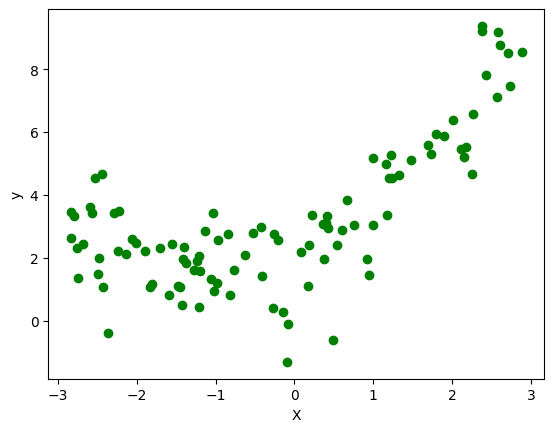

In [10]:
# Plotting the generated dataset

# Plot X vs y using green ('g') using scatter plot.
plt.scatter(X, y, color='g')

# Label the x-axis as 'X'
plt.xlabel('X')

# Label the y-axis as 'y'
plt.ylabel('y')

# Display the plot on the screen
plt.show()

In [12]:
# Splitting the dataset into training and testing sets

# Import the function used to split data into train and test subsets
from sklearn.model_selection import train_test_split

# Split the input features (X) and target values (y)
# 80% of the data will be used for training
# 20% of the data will be used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# First, we implement a simple Linear Regression model

# Import the LinearRegression class from scikit-learn
from sklearn.linear_model import LinearRegression

# Create an instance (object) of the Linear Regression model
regression_1 = LinearRegression()

# Train (fit) the linear regression model using the training data
regression_1.fit(X_train, y_train)

LinearRegression()

In [16]:
# Evaluating the performance of the Linear Regression model using R² score

# Import the R² (coefficient of determination) metric
from sklearn.metrics import r2_score

# Predict output values for the test dataset using the trained linear regression model
# Then calculate the R² score by comparing actual vs predicted values
score = r2_score(y_test, regression_1.predict(X_test))

# Print the R² score
print(score)

0.5170051183836069


In [ ]:
# This result: r2 = 0.5170051183836069 (very less)
# ✔ Confirms that linear regression is insufficient
# ✔ Creates motivation for polynomial features
# ✔ Sets a baseline for comparison
# ✔ Helps you appreciate model complexity

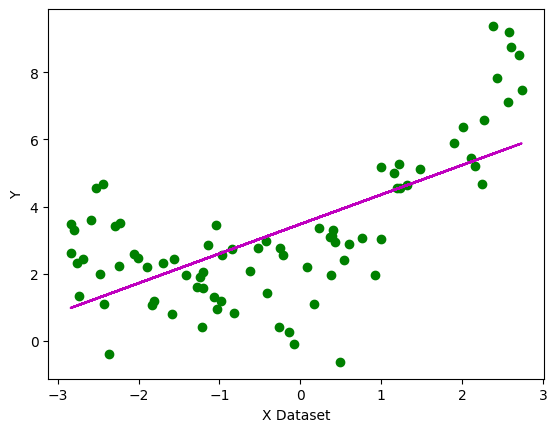

In [18]:
# Visualizing the Linear Regression model on the training dataset

# Plot the predictions made by the linear regression model
# This represents the straight regression line learned by the model
plt.plot(
    X_train,
    regression_1.predict(X_train),
    color='m'  # 'm' stands for magenta color
)

# Plot the actual training data points as green scatter points
plt.scatter(
    X_train,
    y_train,
    color='g'  # 'g' stands for green color
)

# Label the x-axis
plt.xlabel('X Dataset')

# Label the y-axis
plt.ylabel('Y')

# Display the plot
plt.show()
#Clearly, LR is not good here.

In [20]:
# Implementing Polynomial Regression by transforming training and testing data

# Import PolynomialFeatures to generate polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Create a PolynomialFeatures object to generate polynomial terms up to degree 2
# include_bias=True adds a column of ones for the intercept term
poly = PolynomialFeatures(degree=2, include_bias=True)

# Fit the polynomial transformer on the training data
# and transform X_train into polynomial features
X_train_poly = poly.fit_transform(X_train)

# Transform the test data using the same polynomial rules
X_test_poly = poly.fit_transform(X_test)

In [21]:
# Training and evaluating the Polynomial Regression model

# Import the R² score metric to evaluate regression performance
from sklearn.metrics import r2_score

# Create a Linear Regression model
# (Linear regression is used on polynomial-transformed features)
regression = LinearRegression()

# Train the model using polynomial features from the training data
regression.fit(X_train_poly, y_train)

# Predict target values for the polynomial-transformed test data
y_pred = regression.predict(X_test_poly)

# Calculate the R² score by comparing actual and predicted values
score = r2_score(y_test, y_pred)

# Print the R² score
print(score)

0.8065321186395917


In [23]:
# Printing the learned coefficients of the Polynomial Regression model
print(regression.coef_)

[[0.         0.99878871 0.47636685]]


In [25]:
# Printing the intercept (constant term) learned by the Polynomial Regression model
print(regression.intercept_)

[2.1363099]


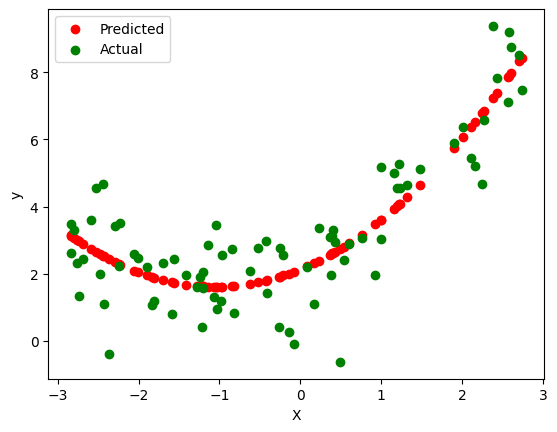

In [29]:
# Plotting the polynomial regression predictions and actual training data

# Plot the predicted values from the polynomial regression model
plt.scatter(
    X_train,
    regression.predict(X_train_poly),
    color='r',        # Red points for predicted values
    label='Predicted' # Add label for legend
)

# Plot the actual training data points
plt.scatter(
    X_train,
    y_train,
    color='g',        # Green points for actual values
    label='Actual'    # Add label for legend
)

# Add axis labels
plt.xlabel('X')
plt.ylabel('y')

# Add legend to distinguish predicted vs actual
plt.legend()

# Display the plot
plt.show()
#Clearly, a good plot is recieved.

In [30]:
# Implementing Polynomial Regression of degree 3 (cubic)

# Import PolynomialFeatures to create polynomial and interaction features
from sklearn.preprocessing import PolynomialFeatures

# Create a PolynomialFeatures object for degree 3
# include_bias=True adds a column of ones for the intercept term
poly = PolynomialFeatures(degree=3, include_bias=True)

# Fit the transformer on the training data and transform it into polynomial features
# This will create features: [1, X, X^2, X^3]
X_train_poly = poly.fit_transform(X_train)

# Transform the test data using the same transformation
# Note: Ideally, we should use transform() here, not fit_transform(),
# to avoid fitting on the test data
X_test_poly = poly.transform(X_test)

In [31]:
# Training and evaluating the Polynomial Regression model

# Import the R² score metric to evaluate regression performance
from sklearn.metrics import r2_score

# Create a Linear Regression model
# (Linear regression is used on polynomial-transformed features)
regression = LinearRegression()

# Train the model using polynomial features from the training data
regression.fit(X_train_poly, y_train)

# Predict target values for the polynomial-transformed test data
y_pred = regression.predict(X_test_poly)

# Calculate the R² score by comparing actual and predicted values
score = r2_score(y_test, y_pred)

# Print the R² score
print(score)
#Clearl, accuracy decreased a bit.

0.8055554468558299


In [34]:
# Generating a smooth range of new input data for prediction and visualization

# Create 200 evenly spaced values between -3 and 3
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
# np.linspace(start, stop, num) generates evenly spaced values
# .reshape(200, 1) converts it into a column vector (required shape for sklearn)

# Transform these new input values into polynomial features
# Use the same transformer fitted on the training data
X_new_poly = poly.transform(X_new)

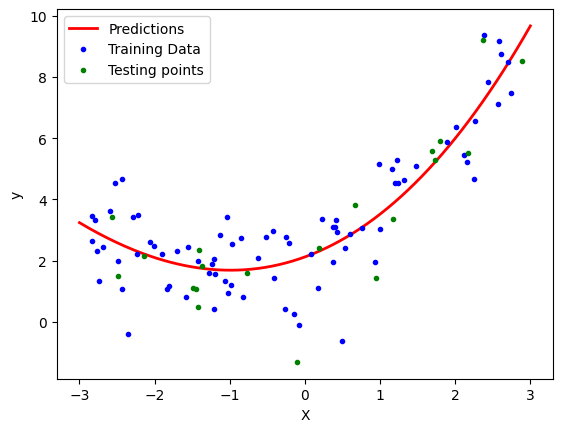

In [36]:
# Predict y values for the smooth input range using the trained model
y_new = regression.predict(X_new_poly)

# Plot the polynomial regression curve
plt.plot(
    X_new,
    y_new,
    "r-",            # Red solid line for predictions
    linewidth=2,     # Line thickness
    label="Predictions"
)

# Plot the training data points
plt.plot(
    X_train,
    y_train,
    "b.",            # Blue dots for training data
    label="Training Data"
)

# Plot the testing data points
plt.plot(
    X_test,
    y_test,
    "g.",            # Green dots for testing data
    label="Testing points"
)

# Add axis labels
plt.xlabel("X")
plt.ylabel("y")

# Add a legend to distinguish curve and points
plt.legend()

# Display the plot
plt.show()